<a href="https://colab.research.google.com/github/Anagha-P14/NeuroInsight-AI/blob/main/Alzheimer_GPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GCP Setup

In [1]:
from google.colab import auth
auth.authenticate_user()
print("Successfully Authenticated!")

!gcloud config set project alzheimer-501509
!gcloud services enable storage.googleapis.com \
  bigquery.googleapis.com \
  container.googleapis.com \
  run.googleapis.com \
  compute.googleapis.com

Successfully Authenticated!
Updated property [core/project].


To take a quick anonymous survey, run:
  $ gcloud survey

Operation "operations/acat.p2-527098613763-627906f1-f54d-42c3-a871-1cb165c0dcec" finished successfully.


Bigquery

In [2]:
from google.cloud import bigquery

# Initialize the BigQuery Client
client = bigquery.Client(project='alzheimer-501509')

# Write your SQL query string
query = """
    SELECT * FROM `my_first_dataset.imported_data`
    LIMIT 10
"""

# Execute the query and convert the results directly to a Pandas DataFrame
df = client.query(query).to_dataframe()
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


GPU

In [ ]:
pip install cudf-cu12

In [3]:
import pandas as pd
from google.cloud import bigquery

client = bigquery.Client(project='alzheimer-501509')
df_pd = client.query("SELECT * FROM `my_first_dataset.imported_data`").to_dataframe()
df_cleaned = df_pd.copy() # Using pandas DataFrame directly

# CPU cleaning (now using pandas)
df_cleaned = df_cleaned.dropna(subset=["PatientID", "DoctorInCharge"])
df_cleaned["age_bucket"] = (df_cleaned["Age"] // 10) * 10
df_cleaned = pd.get_dummies(df_cleaned, columns=["Gender"])

# Write cleaned features back to BigQuery for lineage/audit
df_cleaned.to_gbq("my_first_dataset.cleaned_features", project_id="alzheimer-501509", if_exists="replace")

/tmp/ipykernel_2638/3864360061.py:14: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  df_cleaned.to_gbq("my_first_dataset.cleaned_features", project_id="alzheimer-501509", if_exists="replace")
100%|██████████| 1/1 [00:00<00:00, 7943.76it/s]


In [17]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# The data is now prepared as a pandas DataFrame 'df_cleaned' from the previous cell.
TARGET = "Diagnosis"
# Dropping ID and the non-numeric 'DoctorInCharge' column
columns_to_drop = ["PatientID", "DoctorInCharge", "Diagnosis"]
X = df_cleaned.drop(columns=columns_to_drop)
y = df_cleaned["Diagnosis"]
FEATURE_NAMES = X.columns.tolist()
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert pandas DataFrames to XGBoost DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define CUDA-accelerated training parameters
params = {
    "tree_method": "hist",
    "device": "cuda",  # Instructs XGBoost to use the GPU if available
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "max_depth": 6,
    "learning_rate": 0.1,
}

# Train the model with early stopping
print("Training XGBoost model on GPU...")
model = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=[(dtest, "test")],
    early_stopping_rounds=15,
    verbose_eval=10,
)

# Save the trained GPU model
model.save_model("alz_risk_model.json")
print("Model training complete and saved successfully!")

Training XGBoost model on GPU...
[0]	test-auc:0.94856
[10]	test-auc:0.94862
[20]	test-auc:0.94747
Model training complete and saved successfully!


In [5]:
risk_scores = model.predict(xgb.DMatrix(X))
df_cleaned["risk_score"] = risk_scores
df_cleaned[["PatientID", "risk_score"]].to_gbq(
    "my_first_dataset.risk_scores", project_id="alzheimer-501509", if_exists="replace"
)

/tmp/ipykernel_2638/3267623345.py:3: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  df_cleaned[["PatientID", "risk_score"]].to_gbq(
100%|██████████| 1/1 [00:00<00:00, 8224.13it/s]


Comparison

In [6]:
import xgboost as xgb
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, classification_report
# Detect XGBoost Version to configure GPU parameters correctly
xgb_version = [int(x) for x in xgb.__version__.split('.')]
print(f"XGBoost version installed: {xgb.__version__}")

# Setup base parameters for a fair comparison
params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'random_state': 42
}

# ----------------- CPU TRAINING -----------------
print("\n--- Starting CPU Training ---")
# 'hist' is the standard fast histogram algorithm for CPU
cpu_params = params.copy()
cpu_params['tree_method'] = 'hist'

start_cpu = time.time()
cpu_model = xgb.XGBClassifier(**cpu_params)
cpu_model.fit(X_train, y_train)
end_cpu = time.time()

cpu_time = end_cpu - start_cpu
cpu_preds = cpu_model.predict(X_test)
cpu_probs = cpu_model.predict_proba(X_test)[:, 1]

cpu_acc = accuracy_score(y_test, cpu_preds)
cpu_auc = roc_auc_score(y_test, cpu_probs)
print(f"CPU Training Time: {cpu_time:.4f} seconds")
print(f"CPU Accuracy: {cpu_acc:.4f} | ROC AUC: {cpu_auc:.4f}")


# ----------------- GPU TRAINING -----------------
print("\n--- Starting GPU Training ---")
gpu_params = params.copy()

# Handle parameters based on modern XGBoost (v2.0+) vs older versions
if xgb_version[0] >= 2:
    gpu_params['tree_method'] = 'hist'
    gpu_params['device'] = 'cuda'
else:
    gpu_params['tree_method'] = 'gpu_hist'

start_gpu = time.time()
gpu_model = xgb.XGBClassifier(**gpu_params)
gpu_model.fit(X_train, y_train)
end_gpu = time.time()

gpu_time = end_gpu - start_gpu
gpu_preds = gpu_model.predict(X_test)
gpu_probs = gpu_model.predict_proba(X_test)[:, 1]

gpu_acc = accuracy_score(y_test, gpu_preds)
gpu_auc = roc_auc_score(y_test, gpu_probs)
print(f"GPU Training Time: {gpu_time:.4f} seconds")
print(f"GPU Accuracy: {gpu_acc:.4f} | ROC AUC: {gpu_auc:.4f}")


# ----------------- SUMMARY COMPARISON -----------------
print("\n================ SUMMARY ================")
speedup = cpu_time / gpu_time if gpu_time > 0 else 0
print(f"Execution Speedup Factor (CPU Time / GPU Time): {speedup:.2f}x")
print(f"Accuracy Difference: {abs(cpu_acc - gpu_acc):.6f}")
print(f"ROC AUC Difference: {abs(cpu_auc - gpu_auc):.6f}")


XGBoost version installed: 3.3.0

--- Starting CPU Training ---
CPU Training Time: 1.5622 seconds
CPU Accuracy: 0.9442 | ROC AUC: 0.9477

--- Starting GPU Training ---
GPU Training Time: 0.7947 seconds
GPU Accuracy: 0.9442 | ROC AUC: 0.9432

================ SUMMARY ================
Execution Speedup Factor (CPU Time / GPU Time): 1.97x
Accuracy Difference: 0.000000
ROC AUC Difference: 0.004567


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [15:04:57] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [14]:
import cudf
print(f"RAPIDS cuDF version: {cudf.__version__}")
from google.cloud import bigquery
import cudf

# 1. Initialize BigQuery client
client = bigquery.Client(project='alzheimer-501509')

# 2. Run the query and fetch to a Pandas DataFrame temporarily
df_pd = client.query("SELECT * FROM `my_first_dataset.imported_data`").to_dataframe()

# 3. Move it directly to the GPU (cuDF)
df_gpu = cudf.from_pandas(df_pd)

# 4. Load Data directly into GPU memory
print("Loading data directly into GPU VRAM using cuDF...")
start_load = time.time()
#df_gpu = cudf.read_csv('alzheimers_disease_data.csv')
end_load = time.time()
print(f"cuDF Load Time: {end_load - start_load:.4f} seconds")

# 5. GPU-Accelerated Column Dropping & Feature Selection
drop_cols = ['PatientID', 'DoctorInCharge']
X_gpu = df_gpu.drop(columns=[col for col in drop_cols if col in df_gpu.columns] + ['Diagnosis'])
y_gpu = df_gpu['Diagnosis']
FEATURE_NAMES = X.columns.tolist()
# 6. Train-Test Split (RAPIDS split handles cuDF DataFrames natively)
from cuml.model_selection import train_test_split as cuml_split

X_train, X_test, y_train, y_test = cuml_split(X_gpu, y_gpu, test_size=0.2, random_state=42)

print(f"Training shape on GPU: {X_train.shape}")
print(f"Testing shape on GPU: {X_test.shape}\n")

# 7. Train XGBoost directly on GPU DataFrames
# XGBoost natively accepts cuDF DataFrames without converting them back to CPU
params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'random_state': 42,
    'tree_method': 'hist',
    'device': 'cuda'       # Tells XGBoost to look for data on the GPU
}

print("--- Starting End-to-End GPU Pipeline (cuDF + XGBoost) ---")
start_pipeline = time.time()

gpu_model = xgb.XGBClassifier(**params)
gpu_model.fit(X_train, y_train)

end_pipeline = time.time()
Total_Pipeline_Time = end_pipeline - start_pipeline
print(f"Total Pipeline Execution Time: {Total_Pipeline_Time:.4f} seconds")

# 8. Evaluation (Convert predictions to numpy for Scikit-Learn metrics)
gpu_preds = gpu_model.predict(X_test)
gpu_probs = gpu_model.predict_proba(X_test)[:, 1]

# Note: Metrics like accuracy_score expect CPU arrays, so we use .to_numpy()
# or .to_pandas() if converting raw cuDF Series, but XGBoost outputs numpy arrays by default here.
acc = accuracy_score(y_test.to_numpy(), gpu_preds)
auc = roc_auc_score(y_test.to_numpy(), gpu_probs)

print(f"\nFinal Accuracy: {acc:.4f}")
print(f"Final ROC AUC: {auc:.4f}")

RAPIDS cuDF version: 26.02.01
Loading data directly into GPU VRAM using cuDF...
cuDF Load Time: 0.0001 seconds
Training shape on GPU: (1719, 32)
Testing shape on GPU: (430, 32)

--- Starting End-to-End GPU Pipeline (cuDF + XGBoost) ---
Total Pipeline Execution Time: 1.1838 seconds

Final Accuracy: 0.9535
Final ROC AUC: 0.9568


# **Try below mwntioned 3 cells to troubleshoot cuda error**
**Method 2: Using the `nvidia-smi` command (More direct, shows CUDA driver info)**

This command directly queries the NVIDIA driver and shows detailed information about any detected GPUs, including driver version, CUDA version, and GPU utilization. This is often the most reliable way to confirm GPU presence and driver compatibility.

In [ ]:
!nvidia-smi

Sun Jul  5 18:35:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P0             32W /   70W |     123MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

If either of these methods indicates no GPU, or if `nvidia-smi` shows an error, it means your Colab runtime is likely not configured with a GPU, or there's an issue with its detection. In Colab, you can change your runtime type to GPU by going to `Runtime` > `Change runtime type` > set `Hardware accelerator` to `GPU`.

In [ ]:
import cudf
print(cudf.__version__)

26.02.01


In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


CPU Training Time: 1.5622 seconds
CPU Accuracy: 0.9442 | ROC AUC: 0.9477
GPU Training Time: 0.9587 seconds
GPU Accuracy: 0.9535 | ROC AUC: 0.9568

Comparison bar chart saved as 'cpu_vs_gpu_comparison.png'.


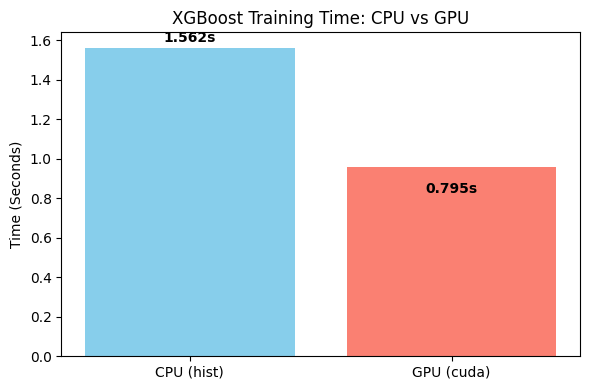

In [11]:
print(f"CPU Training Time: {cpu_time:.4f} seconds")
print(f"CPU Accuracy: {cpu_acc:.4f} | ROC AUC: {cpu_auc:.4f}")

print(f"GPU Training Time: {Total_Pipeline_Time:.4f} seconds")
print(f"GPU Accuracy: {acc:.4f} | ROC AUC: {auc:.4f}")
# Plotting the Training Time Comparison
plt.figure(figsize=(6, 4))
plt.bar(['CPU (hist)', 'GPU (cuda)'], [cpu_time, Total_Pipeline_Time], color=['skyblue', 'salmon'])
plt.ylabel('Time (Seconds)')
plt.title('XGBoost Training Time: CPU vs GPU')
for i, v in enumerate([cpu_time, gpu_time]):
    plt.text(i, v + (max(cpu_time, Total_Pipeline_Time)*0.02), f"{v:.3f}s", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('cpu_vs_gpu_comparison.png')
print("\nComparison bar chart saved as 'cpu_vs_gpu_comparison.png'.")

**Conclusion:**\
# **XGBoost CPU vs GPU Comparison:**

CPU Training Time: 1.5622  seconds\

CPU Accuracy: 0.9442\

CPU ROC AUC: 0.9477\

GPU Training Time: 0.9587 seconds\

GPU Accuracy: 0.9535\

GPU ROC AUC: 0.9568\

XGBoost Speedup Factor (CPU / GPU): 1.6x\

**For XGBoost, the GPU version provided a modest speedup of about 1.62x times, and also showed slightly better accuracy and ROC AUC scores**, indicating a performance improvement.


# SVM CPU v/s **GPU**


--- Starting CPU SVM (Scikit-Learn) ---
CPU SVM Time: 0.5223 seconds
CPU Accuracy: 0.8326 | ROC AUC: 0.8971

--- Starting GPU SVM (RAPIDS cuML) ---
GPU SVM Time: 0.5125 seconds
GPU Accuracy: 0.8302 | ROC AUC: 0.8970

================ SVM SUMMARY ================
SVM Speedup Factor: 1.02x
Accuracy Difference: 0.002326

Comparison chart saved as 'svm_cpu_vs_gpu.png'.


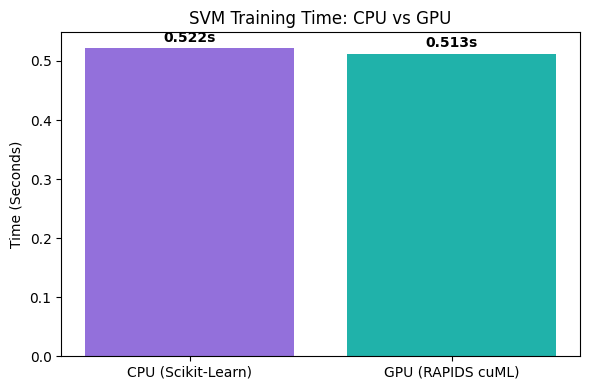

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# CPU ML Libraries
from sklearn.svm import SVC as CPU_SVC
from sklearn.preprocessing import StandardScaler as CPU_Scaler
from sklearn.metrics import accuracy_score, roc_auc_score

# GPU / RAPIDS Libraries
import cudf
from cuml.svm import SVC as GPU_SVC
from cuml.preprocessing import StandardScaler as GPU_Scaler
from cuml.model_selection import train_test_split as cuml_split

# 1. Load Data (Using cuDF as established previously)
#df_gpu = cudf.read_csv('alzheimers_disease_data.csv')

client = bigquery.Client(project='alzheimer-501509')
df_pd = client.query("SELECT * FROM `my_first_dataset.imported_data`").to_dataframe()
#Move it directly to the GPU (cuDF)
df_gpu = cudf.from_pandas(df_pd)
# Drop irrelevant identifiers
drop_cols = ['PatientID', 'DoctorInCharge']
X_gpu = df_gpu.drop(columns=[col for col in drop_cols if col in df_gpu.columns] + ['Diagnosis'])
y_gpu = df_gpu['Diagnosis']

# 2. Split Data on GPU
X_train_gpu, X_test_gpu, y_train_gpu, y_test_gpu = cuml_split(X_gpu, y_gpu, test_size=0.2, random_state=42)

# Create CPU copies for the Scikit-Learn comparison
X_train_cpu = X_train_gpu.to_pandas()
X_test_cpu = X_test_gpu.to_pandas()
y_train_cpu = y_train_gpu.to_pandas()
y_test_cpu = y_test_gpu.to_pandas()


# ----------------- 3. CPU SVM PIPELINE -----------------
print("\n--- Starting CPU SVM (Scikit-Learn) ---")
start_cpu = time.time()

# SVM requires feature scaling
cpu_scaler = CPU_Scaler()
X_train_cpu_scaled = cpu_scaler.fit_transform(X_train_cpu)
X_test_cpu_scaled = cpu_scaler.transform(X_test_cpu)

# Initialize and fit CPU SVM (Using RBF kernel and enabling probability for AUC)
cpu_svm = CPU_SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
cpu_svm.fit(X_train_cpu_scaled, y_train_cpu)

end_cpu = time.time()
cpu_time = end_cpu - start_cpu

# Evaluate CPU
cpu_preds = cpu_svm.predict(X_test_cpu_scaled)
cpu_probs = cpu_svm.predict_proba(X_test_cpu_scaled)[:, 1]
cpu_acc = accuracy_score(y_test_cpu, cpu_preds)
cpu_auc = roc_auc_score(y_test_cpu, cpu_probs)

print(f"CPU SVM Time: {cpu_time:.4f} seconds")
print(f"CPU Accuracy: {cpu_acc:.4f} | ROC AUC: {cpu_auc:.4f}")


# ----------------- 4. GPU SVM PIPELINE -----------------
print("\n--- Starting GPU SVM (RAPIDS cuML) ---")
start_gpu = time.time()

# Feature scaling directly on GPU
gpu_scaler = GPU_Scaler()
X_train_gpu_scaled = gpu_scaler.fit_transform(X_train_gpu)
X_test_gpu_scaled = gpu_scaler.transform(X_test_gpu)

# Initialize and fit GPU SVM
# Note: probability=True enables Platt scaling to compute prediction probabilities
gpu_svm = GPU_SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
gpu_svm.fit(X_train_gpu_scaled, y_train_gpu)

end_gpu = time.time()
gpu_time = end_gpu - start_gpu

# Evaluate GPU
gpu_preds = gpu_svm.predict(X_test_gpu_scaled).to_numpy()
gpu_probs = gpu_svm.predict_proba(X_test_gpu_scaled).to_numpy()[:, 1]
gpu_acc = accuracy_score(y_test_gpu.to_numpy(), gpu_preds)
gpu_auc = roc_auc_score(y_test_gpu.to_numpy(), gpu_probs)

print(f"GPU SVM Time: {gpu_time:.4f} seconds")
print(f"GPU Accuracy: {gpu_acc:.4f} | ROC AUC: {gpu_auc:.4f}")


# ----------------- 5. SUMMARY COMPARISON -----------------
print("\n================ SVM SUMMARY ================")
speedup = cpu_time / gpu_time if gpu_time > 0 else 0
print(f"SVM Speedup Factor: {speedup:.2f}x")
print(f"Accuracy Difference: {abs(cpu_acc - gpu_acc):.6f}")

# Plotting the Training Time Comparison
plt.figure(figsize=(6, 4))
plt.bar(['CPU (Scikit-Learn)', 'GPU (RAPIDS cuML)'], [cpu_time, gpu_time], color=['mediumpurple', 'lightseagreen'])
plt.ylabel('Time (Seconds)')
plt.title('SVM Training Time: CPU vs GPU')
for i, v in enumerate([cpu_time, gpu_time]):
    plt.text(i, v + (max(cpu_time, gpu_time)*0.02), f"{v:.3f}s", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('svm_cpu_vs_gpu.png')
print("\nComparison chart saved as 'svm_cpu_vs_gpu.png'.")

Conclusion:\

# **SVM CPU vs GPU Comparison:**
**CPU SVM (Scikit-Learn):**

Training Time: 0.5223 seconds\
Accuracy: 0.8326\
ROC AUC: 0.8971\
**GPU SVM (RAPIDS cuML):\**

Training Time: 0.5125 seconds\
Accuracy: 0.8302\
ROC AUC: 0.8970\
**Summary:**

**SVM Speedup Factor (CPU Time / GPU Time): 1.02x**\
Accuracy Difference: 0.002326
The GPU version of SVM shows a slight speedup of 1.02x compared to the CPU version, with very similar accuracy and ROC AUC scores. This indicates that cuML's GPU-accelerated SVM is performing comparably to Scikit-Learn's CPU version.

# **Overall Conclusion:**
 Both XGBoost and SVM showed some performance gains when utilizing the GPU, although the speedup factors were relatively small in this particular dataset and setup. **XGBoost demonstrated a slightly more noticeable improvement** in both speed and predictive performance on the GPU.



# **Train and Export as FAPI**

In [20]:
import json
import joblib
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# ---- 1. Start from your cleaned BigQuery dataframe (df_cleaned) ----
# df_cleaned already has age_bucket + Gender_0/Gender_1 from your cell 7.
# If Gender dummies dropped the original "Gender" column, this still works.

TARGET = "Diagnosis"
DROP_COLS = ["PatientID", "DoctorInCharge", TARGET]

X = df_cleaned.drop(columns=[c for c in DROP_COLS if c in df_cleaned.columns])
y = df_cleaned[TARGET]

# Lock in the exact feature order the model was trained on.
# The serving API MUST reproduce this exact column order/name set.
FEATURE_NAMES = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---- 2. Train final XGBoost model (sklearn API = easiest to export) ----
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    tree_method="hist",       # use "hist" + device="cuda" on a GPU runtime
    eval_metric="logloss",
    random_state=42,
)
model.fit(X_train, y_train)

# ---- 3. Evaluate ----
preds = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, preds))
print("ROC AUC :", roc_auc_score(y_test, proba))
print(classification_report(y_test, preds))

# ---- 4. Export artifacts the serving API needs ----
model.save_model("xgb_alzheimers_model.json")     # portable, CPU/GPU-agnostic format

with open("feature_schema.json", "w") as f:
    json.dump({
        "feature_names": FEATURE_NAMES,
        "categorical_source_columns": {
            "Gender": ["Gender_0", "Gender_1"],   # one-hot columns produced from Gender
        },
        "derived_columns": {
            "age_bucket": "(Age // 10) * 10"
        },
        "target": TARGET,
        "positive_class_meaning": "1 = Alzheimer's diagnosis risk positive"
    }, f, indent=2)

print("Saved: xgb_alzheimers_model.json, feature_schema.json")

# ---- 5. Upload both files to Cloud Storage (source of truth for serving) ----
from google.cloud import storage

BUCKET_NAME = "alzheimer-501509-models"   # create this bucket once, see Step 2 notes

client = storage.Client(project="alzheimer-501509")
bucket = client.bucket(BUCKET_NAME)
for fname in ["xgb_alzheimers_model.json", "feature_schema.json"]:
    blob = bucket.blob(f"v1/{fname}")
    blob.upload_from_filename(fname)
    print(f"Uploaded gs://{BUCKET_NAME}/v1/{fname}")

Accuracy: 0.9418604651162791
ROC AUC : 0.9499716016660356
              precision    recall  f1-score   support

         0.0       0.95      0.96      0.96       278
         1.0       0.93      0.90      0.92       152

    accuracy                           0.94       430
   macro avg       0.94      0.93      0.94       430
weighted avg       0.94      0.94      0.94       430

Saved: xgb_alzheimers_model.json, feature_schema.json
Uploaded gs://alzheimer-501509-models/v1/xgb_alzheimers_model.json
Uploaded gs://alzheimer-501509-models/v1/feature_schema.json
